# Import the data and analyze

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Preprocessing & feature selection
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_classif

# Model selection & evaluation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV,
    learning_curve,
    KFold
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

# Statistical tests & distributions
import scipy.stats as stats
from scipy.stats import ttest_ind, randint, uniform

# Imbalanced-data handling
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTEENN
from imblearn.ensemble import BalancedBaggingClassifier

# Models
from sklearn.ensemble import  RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./bank-additional-full.csv',sep = ';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [3]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [5]:
df.shape

(41188, 21)

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df.describe(include='object').T

,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


# Checking the unknown variables

In [8]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

frames = []

for column in categorical_columns:
    unique_values = df[column].unique()
    # Create a DataFrame for each column's unique values
    temp_df = pd.DataFrame({'Column Name': column, 'Unique Values': [unique_values]})
    frames.append(temp_df)

# Concatenate all DataFrames in the list
unique_values_df = pd.concat(frames, ignore_index=True)
pd.set_option('display.max_colwidth', None)

display(unique_values_df)

,Column Name,Unique Values
0,job,"[housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, unknown, entrepreneur, student]"
1,marital,"[married, single, divorced, unknown]"
2,education,"[basic.4y, high.school, basic.6y, basic.9y, professional.course, unknown, university.degree, illiterate]"
3,default,"[no, unknown, yes]"
4,housing,"[no, yes, unknown]"
5,loan,"[no, yes, unknown]"
6,contact,"[telephone, cellular]"
7,month,"[may, jun, jul, aug, oct, nov, dec, mar, apr, sep]"
8,day_of_week,"[mon, tue, wed, thu, fri]"
9,poutcome,"[nonexistent, failure, success]"


# Null and duplicate check

In [9]:
columns_of_interest = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']

unknown_rows = df[df[columns_of_interest].apply(lambda row: 'unknown' in row.values, axis=1)]

print("Number of records containing 'unknown' values in all columns is : ",unknown_rows.shape[0])

Number of records containing 'unknown' values in all columns is :  10700


In [10]:
df[(df['job'] == 'unknown')  &
                     (df['education'] == 'unknown') &
                      (df['default'] == 'unknown') & (df['housing'] == 'unknown') &
                     (df['loan'] == 'unknown')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
2723,45,unknown,married,unknown,unknown,unknown,unknown,telephone,may,wed,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,no
21556,44,unknown,married,unknown,unknown,unknown,unknown,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,no


In [11]:
df[(df['education']=='unknown')
& (df['job']=='unknown')
& (df['marital']=='unknown') & (df['default']=='unknown')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
17344,49,unknown,unknown,unknown,unknown,yes,yes,cellular,jul,mon,...,9,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
17421,55,unknown,unknown,unknown,unknown,yes,no,cellular,jul,mon,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no


In [12]:
df.drop(index=[17344,17421,2723,21556],axis=0,inplace=True)

In [13]:
df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            326
Name: count, dtype: int64

In [14]:
df.duplicated().sum()

12

In [15]:
duplicate_ratio =  df.duplicated().sum() / len(df)
print("Duplicates percenatage :", duplicate_ratio*100)

Duplicates percenatage : 0.029137529137529136


In [16]:
df[df.duplicated(keep=False)].head(20)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [17]:
df.drop_duplicates(keep='first',inplace=True)

In [18]:
df.duplicated().sum()

0

In [19]:
print("Number of rows after dropping duplicates : ",df.shape[0])

Number of rows after dropping duplicates :  41172


In [20]:
df['y'].value_counts()

y
no     36533
yes     4639
Name: count, dtype: int64

# Find and remove outliers

In [21]:
def find_outliers(df):

  q1=df.quantile(0.25)

  q3=df.quantile(0.75)

  IQR=q3-q1

  outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]

  return outliers

In [22]:
outliers = find_outliers(df['age'])
print("Number of outliers in Age ",":", str(len(outliers)),", Percentage is : ",str(len(outliers)*100/len(df)),"%")
print("\n")

Number of outliers in Age  : 468 , Percentage is :  1.1366948411541824 %




In [23]:
def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    IQR = q3 - q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

df = remove_outliers(df, 'age')

In [24]:
outliers = find_outliers(df['age'])
print("Number of outliers in Age ",":", str(len(outliers)),",It's Percentage is : ",str(len(outliers)*100/len(df)),"%")
print("\n")

Number of outliers in Age  : 0 ,It's Percentage is :  0.0 %




In [25]:
print("Number of columns in our dataset before encoding : ",df.shape[1])

Number of columns in our dataset before encoding :  21


In [26]:
for col in df.select_dtypes(include=['object']):
  print("Number of unique categories in column  ", col," is : ", df[col].nunique())
  print("\n")

Number of unique categories in column   job  is :  12


Number of unique categories in column   marital  is :  4


Number of unique categories in column   education  is :  8


Number of unique categories in column   default  is :  3


Number of unique categories in column   housing  is :  3


Number of unique categories in column   loan  is :  3


Number of unique categories in column   contact  is :  2


Number of unique categories in column   month  is :  10


Number of unique categories in column   day_of_week  is :  5


Number of unique categories in column   poutcome  is :  3


Number of unique categories in column   y  is :  2




In [27]:
outliers = find_outliers(df['age'])
print("Number of outliers in Age ",":", str(len(outliers)),",It's Percentage is : ",str(len(outliers)*100/len(df)),"%")
print("\n")

Number of outliers in Age  : 0 ,It's Percentage is :  0.0 %




# Encoding

In [28]:
print(" Education categories before applying Ordinal encoding : \n",df['education'].unique())

 Education categories before applying Ordinal encoding : 
 ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']


In [29]:
ordinal_encoder = OrdinalEncoder()
df['education'] = ordinal_encoder.fit_transform(df[['education']])

In [30]:
print("Education categories after applying Ordinal encoding : \n",df['education'].unique())

Education categories after applying Ordinal encoding : 
 [0. 3. 1. 2. 5. 7. 6. 4.]


In [31]:
df['education']=df['education'].replace(7,-1)

In [32]:
df['education'].unique()

array([ 0.,  3.,  1.,  2.,  5., -1.,  6.,  4.])

In [33]:
df = pd.get_dummies(data = df,columns=['contact','marital'])

In [34]:
label_encoder = LabelEncoder()

In [35]:
df['job'] = df['job'].astype(str).replace('unknown', '-1')

In [36]:
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', '-1',
       'entrepreneur', 'student'], dtype=object)

In [37]:
df['job'] = label_encoder.fit_transform(df['job'])

In [38]:
df['job'].unique()

array([ 4,  8,  1,  2, 10,  6,  5, 11,  7,  0,  3,  9])

In [39]:
df['job'] = df['job'].replace(0, -1)

In [40]:
df['day_of_week'].unique()

array(['mon', 'tue', 'wed', 'thu', 'fri'], dtype=object)

In [41]:
df['day_of_week'] = label_encoder.fit_transform(df['day_of_week'])

In [42]:
df['month'].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr',
       'sep'], dtype=object)

In [43]:
month_mapping = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

# Encode the 'Month' column based on the dictionary mapping
df['month'] = df['month'].map(month_mapping)

In [44]:
df['month'].unique()

array([ 5,  6,  7,  8, 10, 11, 12,  3,  4,  9], dtype=int64)

In [45]:
df['housing'] = df['housing'].map({'yes': 1,'unknown': -1,'no': 0})

df['loan'] = df['loan'].map({'yes': 1,'unknown': -1,'no': 0})

df['default'] = df['default'].map({'yes': 1,'unknown': -1,'no': 0})

df['poutcome'] = df['poutcome'].map({'success': 1,'nonexistent': -1,'failure': 0})

In [46]:
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

In [47]:
print("Number of columns after encoding : ",df.shape[1])

Number of columns after encoding :  25


In [48]:
df['y'].value_counts()

y
0    36533
1     4639
Name: count, dtype: int64

# Visualization (Boxplot)

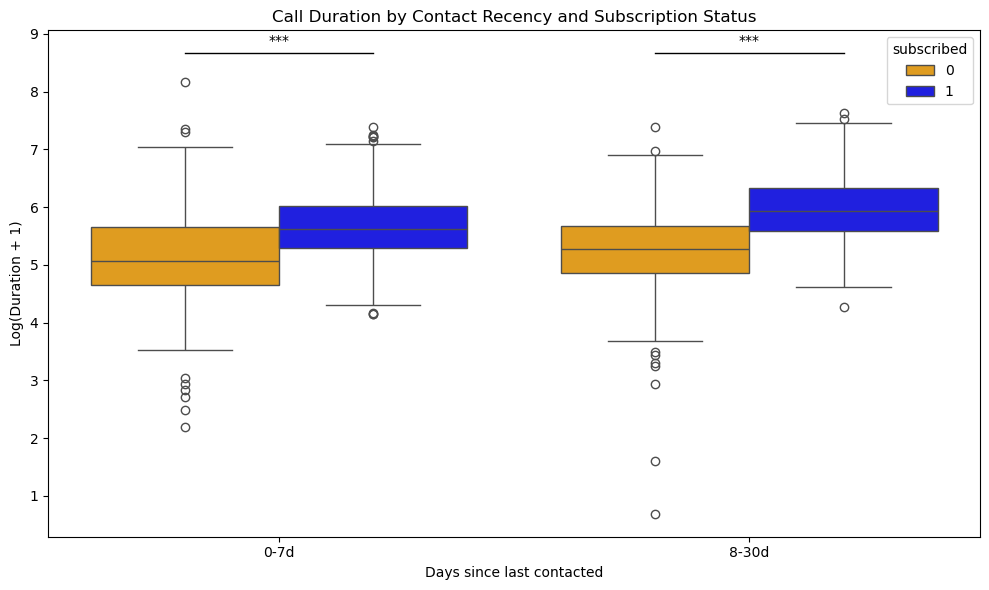

In [49]:

# Make a copy and filter out non-contacted clients
df_plot = df[df['pdays'] < 999].copy()

# Create recency bins on the copy only
df_plot['recency_bin'] = pd.cut(
    df_plot['pdays'],
    bins=[0, 7, 30, 90],
    labels=['0-7d', '8-30d', '31-90d']
)

# Rename for clarity
df_plot['subscribed'] = df_plot['y']

# Plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_plot,
    x='recency_bin',
    y=np.log1p(df_plot['duration']),
    hue='subscribed',
    palette={0: 'orange', 1: 'blue'}
)

# Add significance markers
max_log_duration = np.log1p(df_plot['duration'].max())
for i, group in enumerate(['0-7d', '8-30d', '31-90d']):
    g = df_plot[df_plot['recency_bin'] == group]
    sub = g[g['subscribed'] == 1]['duration']
    nonsub = g[g['subscribed'] == 0]['duration']
    if len(sub) > 0 and len(nonsub) > 0:
        t, p = ttest_ind(sub, nonsub)
        if p < 0.05:
            y = max_log_duration + 0.5
            plt.plot([i - 0.2, i + 0.2], [y, y], lw=1, c='black')
            stars = '*' * (3 if p < 0.001 else 2 if p < 0.01 else 1)
            plt.text(i, y + 0.1, stars, ha='center', va='bottom', c='black')

plt.title('Call Duration by Contact Recency and Subscription Status')
plt.ylabel('Log(Duration + 1)')
plt.xlabel('Days since last contacted')
plt.tight_layout()
plt.show()

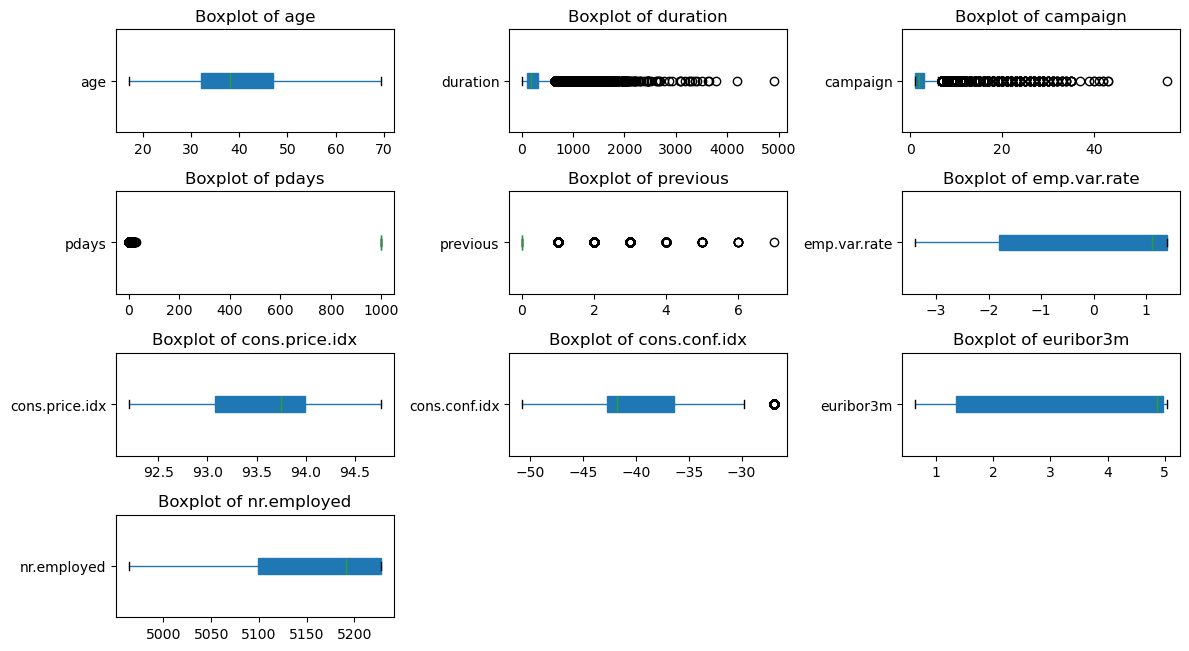

In [50]:
X = ['age', 'duration', 'campaign', 'pdays','previous', 
     'emp.var.rate', 'cons.price.idx','cons.conf.idx', 
     'euribor3m', 'nr.employed']

# Create subplots (5 rows, 2 columns for 10 features)
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(12, 8))
axes = axes.flatten()  # Flatten the 2D array to 1D for easy indexing

# Plot each variable
for i, col in enumerate(X):
    df.boxplot(column=[col], grid=False,  vert = False,patch_artist=True, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    
# Remove unused axes if any (in case of mismatch)
for j in range(len(X), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Correlation

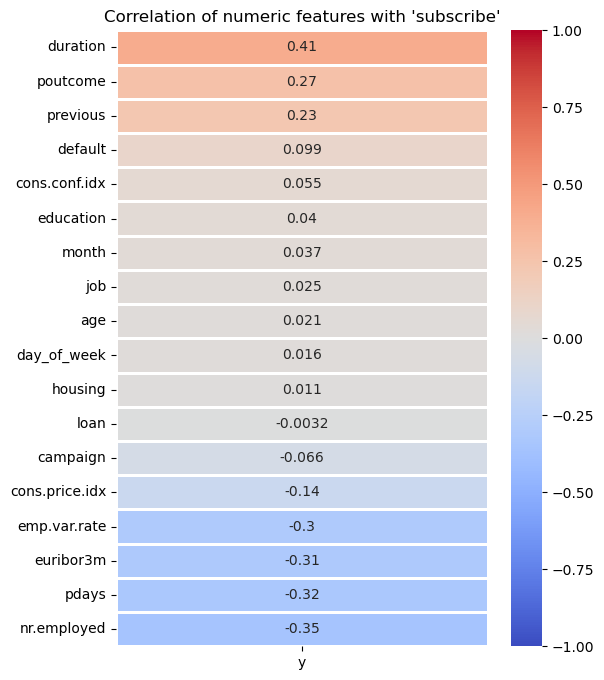

In [51]:
# Assuming 'subscribe' is still categorical like 'yes'/'no'
# Convert it temporarily for correlation
df_temp = df.copy()
df_temp['y'] = df_temp['y']

num_col = df_temp.select_dtypes(include=[np.number]).columns.tolist()
correlation = df_temp[num_col].corr()

subscribe_corr = correlation[['y']].drop('y').sort_values(by='y', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(subscribe_corr, cmap='coolwarm', annot=True, linewidth=2, vmin=-1, vmax=1)
plt.title("Correlation of numeric features with 'subscribe'")
plt.show()

# ANOVA Test

In [52]:
X = df.drop(['y'],axis=1)
y =df.y

In [53]:
X

,age,job,education,default,housing,loan,month,day_of_week,duration,campaign,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,contact_cellular,contact_telephone,marital_divorced,marital_married,marital_single,marital_unknown
0,56.0,4,0.0,0,0,0,5,1,261,1,...,93.994,-36.4,4.857,5191.0,False,True,False,True,False,False
1,57.0,8,3.0,-1,0,0,5,1,149,1,...,93.994,-36.4,4.857,5191.0,False,True,False,True,False,False
2,37.0,8,3.0,0,1,0,5,1,226,1,...,93.994,-36.4,4.857,5191.0,False,True,False,True,False,False
3,40.0,1,1.0,0,0,0,5,1,151,1,...,93.994,-36.4,4.857,5191.0,False,True,False,True,False,False
4,56.0,8,3.0,0,0,1,5,1,307,1,...,93.994,-36.4,4.857,5191.0,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,69.5,6,5.0,0,1,0,11,0,334,1,...,94.767,-50.8,1.028,4963.6,True,False,False,True,False,False
41184,46.0,2,5.0,0,0,0,11,0,383,1,...,94.767,-50.8,1.028,4963.6,True,False,False,True,False,False
41185,56.0,6,6.0,0,1,0,11,0,189,2,...,94.767,-50.8,1.028,4963.6,True,False,False,True,False,False
41186,44.0,10,5.0,0,0,0,11,0,442,1,...,94.767,-50.8,1.028,4963.6,True,False,False,True,False,False


In [54]:
# Assuming x is your feature DataFrame and y is your target

# Apply ANOVA F-test
f_values, p_values = f_classif(X, y)

# Create a summary DataFrame
anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F-Statistic': f_values,
    'p-Value': p_values
})

# Sort by F-Statistic descending (most significant first)
anova_results = anova_results.sort_values(by='F-Statistic', ascending=False)

print("ANOVA Test Results:")
print(anova_results)

# OPTIONAL: Select top k features
k = 10
selector = SelectKBest(score_func=f_classif, k=k)
X_new = selector.fit_transform(X, y)

# Get selected feature names
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]

print("\nTop", k, "Selected Features:")
print(selected_features.tolist())

ANOVA Test Results:
              Feature  F-Statistic        p-Value
8            duration  8091.749933   0.000000e+00
17        nr.employed  5923.459763   0.000000e+00
10              pdays  4860.252992   0.000000e+00
16          euribor3m  4306.359239   0.000000e+00
13       emp.var.rate  4020.422845   0.000000e+00
12           poutcome  3247.376574   0.000000e+00
11           previous  2303.599729   0.000000e+00
18   contact_cellular   881.568925  1.056577e-191
19  contact_telephone   881.568925  1.056577e-191
14     cons.price.idx   777.253528  1.799383e-169
3             default   408.847603   1.799061e-90
9            campaign   182.104638   2.060919e-41
15      cons.conf.idx   124.058717   8.991723e-29
22     marital_single   121.246173   3.695319e-28
21    marital_married    78.000665   1.069782e-18
2           education    65.690857   5.419194e-16
6               month    57.091598   4.245784e-14
1                 job    26.614396   2.495357e-07
0                 age    18.07

# Scaling and Splitting of data

In [55]:
standard_scaler = StandardScaler()
df_scaled=df.copy()
columns = df.drop(['y'],axis=1).columns
for col in columns:
    df_scaled[col] = standard_scaler.fit_transform(np.array(df_scaled[col]).reshape(-1,1))

In [56]:
df_scaled

,age,job,education,default,housing,loan,month,day_of_week,duration,campaign,...,cons.conf.idx,euribor3m,nr.employed,y,contact_cellular,contact_telephone,marital_divorced,marital_married,marital_single,marital_unknown
0,1.585741,-0.173818,-1.532859,0.513197,-0.915716,-0.319921,-0.787689,-0.718755,0.010313,-0.565964,...,0.886570,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567
1,1.684470,0.946605,-0.184787,-1.946851,-0.915716,-0.319921,-0.787689,-0.718755,-0.421600,-0.565964,...,0.886570,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567
2,-0.290108,0.946605,-0.184787,0.513197,0.916161,-0.319921,-0.787689,-0.718755,-0.124660,-0.565964,...,0.886570,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567
3,0.006079,-1.014135,-1.083502,0.513197,-0.915716,-0.319921,-0.787689,-0.718755,-0.413887,-0.565964,...,0.886570,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567
4,1.585741,0.946605,-0.184787,0.513197,-0.915716,2.184696,-0.787689,-0.718755,0.187705,-0.565964,...,0.886570,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,2.918581,0.386394,0.713927,0.513197,0.916161,-0.319921,2.151962,-1.434225,0.291827,-0.565964,...,-2.224987,-1.495092,-2.815559,1,0.758643,-0.758643,-0.355131,0.80761,-0.624956,-0.043567
41184,0.598452,-0.734029,0.713927,0.513197,-0.915716,-0.319921,2.151962,-1.434225,0.480788,-0.565964,...,-2.224987,-1.495092,-2.815559,0,0.758643,-0.758643,-0.355131,0.80761,-0.624956,-0.043567
41185,1.585741,0.386394,1.163284,0.513197,0.916161,-0.319921,2.151962,-1.434225,-0.267345,-0.204980,...,-2.224987,-1.495092,-2.815559,0,0.758643,-0.758643,-0.355131,0.80761,-0.624956,-0.043567
41186,0.400994,1.506817,0.713927,0.513197,-0.915716,-0.319921,2.151962,-1.434225,0.708314,-0.565964,...,-2.224987,-1.495092,-2.815559,1,0.758643,-0.758643,-0.355131,0.80761,-0.624956,-0.043567


In [57]:
X.shape

(41172, 24)

In [58]:
X = df_scaled.drop(["y","emp.var.rate" ,"cons.price.idx","cons.conf.idx", "euribor3m", "nr.employed","job"],axis=1)
y = df_scaled.y

In [59]:
df_scaled.head()

,age,job,education,default,housing,loan,month,day_of_week,duration,campaign,...,cons.conf.idx,euribor3m,nr.employed,y,contact_cellular,contact_telephone,marital_divorced,marital_married,marital_single,marital_unknown
0,1.585741,-0.173818,-1.532859,0.513197,-0.915716,-0.319921,-0.787689,-0.718755,0.010313,-0.565964,...,0.88657,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567
1,1.684470,0.946605,-0.184787,-1.946851,-0.915716,-0.319921,-0.787689,-0.718755,-0.421600,-0.565964,...,0.88657,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567
2,-0.290108,0.946605,-0.184787,0.513197,0.916161,-0.319921,-0.787689,-0.718755,-0.124660,-0.565964,...,0.88657,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567
3,0.006079,-1.014135,-1.083502,0.513197,-0.915716,-0.319921,-0.787689,-0.718755,-0.413887,-0.565964,...,0.88657,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567
4,1.585741,0.946605,-0.184787,0.513197,-0.915716,2.184696,-0.787689,-0.718755,0.187705,-0.565964,...,0.88657,0.712522,0.331758,0,-1.318143,1.318143,-0.355131,0.80761,-0.624956,-0.043567


# Split the data

In [60]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# UpSampling

In [61]:
class_0_count = np.sum(y_train == 0)
class_1_count = np.sum(y_train == 1)

# Calculate the ratio between the two classes
class_ratio = class_0_count / class_1_count if class_1_count != 0 else np.inf

print(f"Class 0 count: {class_0_count}")
print(f"Class 1 count: {class_1_count}")
print(f"Ratio (Class 0 : Class 1): {class_ratio:.2f}")

Class 0 count: 25640
Class 1 count: 3180
Ratio (Class 0 : Class 1): 8.06


In [62]:
enn_params = {'n_neighbors': 3, 'kind_sel': 'all'}
enn = EditedNearestNeighbours(**enn_params)

smote_enn = SMOTEENN(random_state=42,sampling_strategy=0.7, enn=enn)
x_resampled, y_resampled = smote_enn.fit_resample(x_train, y_train)

In [63]:
print("Before UpSampling, counts of class '0': {}".format(sum(y_train==0)))
print("Before UpSampling, counts of class '1': {} \n".format(sum(y_train==1)))


print("After UpSampling, counts of class '0': {}".format(sum(y_resampled==0)))
print("After UpSampling, counts of class '1': {} \n".format(sum(y_resampled==1)))

Before UpSampling, counts of class '0': 25640
Before UpSampling, counts of class '1': 3180 

After UpSampling, counts of class '0': 21000
After UpSampling, counts of class '1': 17948 



# With Resampled data


Logistic Regression Metrics:
Accuracy:  0.8036
AUC:       0.8883
Precision: 0.3552
Recall:    0.8129
F1-Score:  0.4944
Confusion Matrix:
[[8740 2153]
 [ 273 1186]]


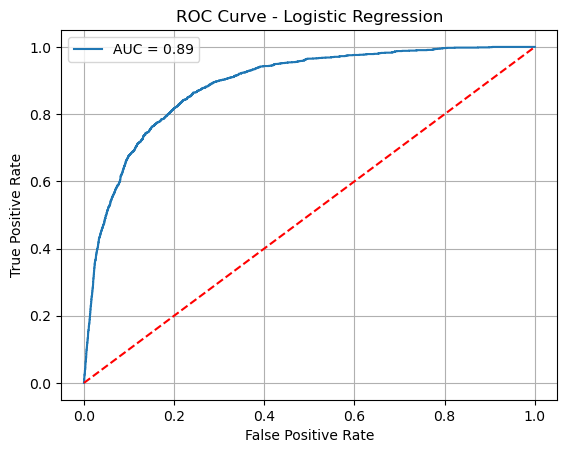

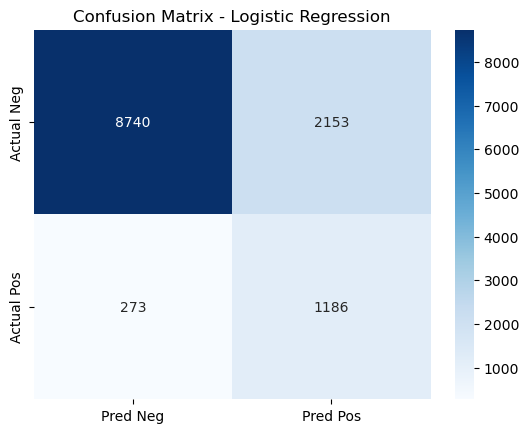

In [64]:
# Train and evaluate Logistic Regression
log_reg = LogisticRegression(class_weight='balanced')
log_reg.fit(x_resampled, y_resampled)
y_pred = log_reg.predict(x_test)
y_prob = log_reg.predict_proba(x_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_prob)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nLogistic Regression Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"AUC:       {auc_val:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_val:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


SVM Metrics:
Accuracy:  0.8009 | AUC: 0.8866 | Precision: 0.3523 | Recall: 0.8177 | F1: 0.4925
Confusion Matrix:
[[8700 2193]
 [ 266 1193]]


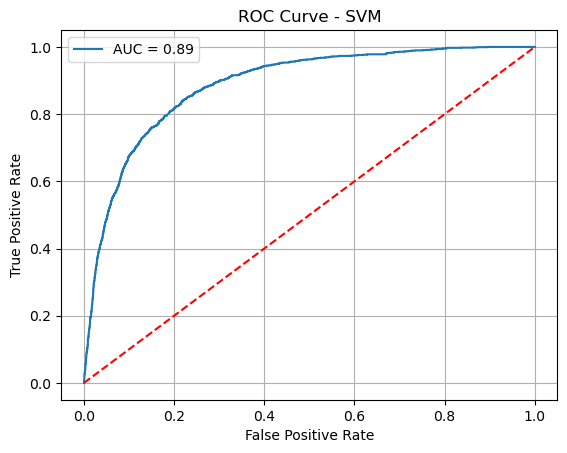

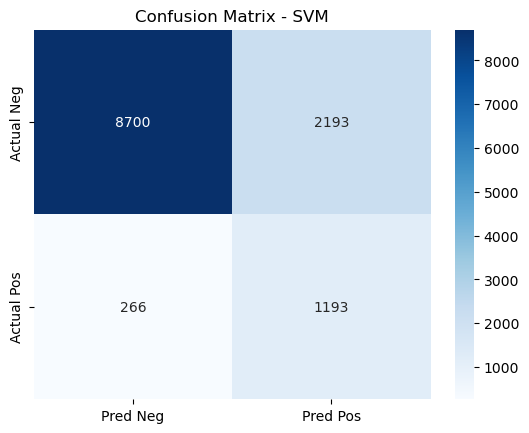

In [65]:
# SVM
svm = SVC(kernel='linear', probability=True, class_weight='balanced')
svm.fit(x_resampled, y_resampled)
y_pred = svm.predict(x_test)
y_prob = svm.predict_proba(x_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_prob)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nSVM Metrics:")
print(f"Accuracy:  {acc:.4f} | AUC: {auc_val:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_val:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('ROC Curve - SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])
plt.title('Confusion Matrix - SVM')
plt.show()


Decision Tree Metrics:
Accuracy:  0.8584 | AUC: 0.8049 | Precision: 0.4404 | Recall: 0.7347 | F1: 0.5507
Confusion Matrix:
[[9531 1362]
 [ 387 1072]]


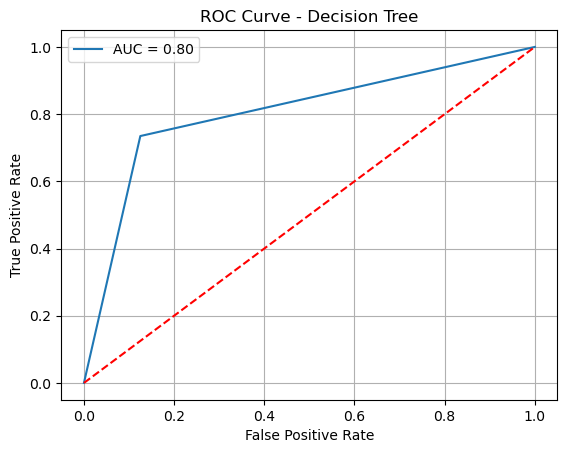

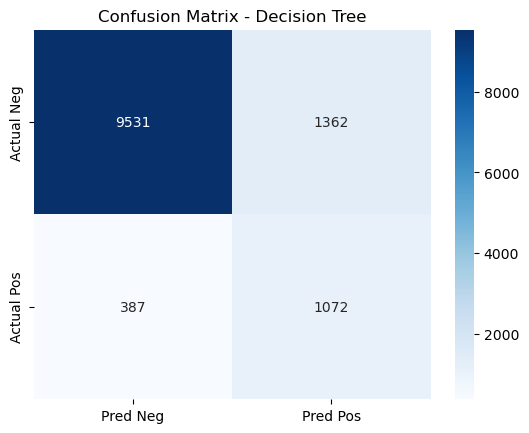

In [66]:
# Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
decision_tree.fit(x_resampled, y_resampled)
y_pred = decision_tree.predict(x_test)
y_prob = decision_tree.predict_proba(x_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_prob)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nDecision Tree Metrics:")
print(f"Accuracy:  {acc:.4f} | AUC: {auc_val:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_val:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('ROC Curve - Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])
plt.title('Confusion Matrix - Decision Tree')
plt.show()


Random Forest Metrics:
Accuracy:  0.8744 | AUC: 0.9199 | Precision: 0.4808 | Recall: 0.7992 | F1: 0.6004
Confusion Matrix:
[[9634 1259]
 [ 293 1166]]


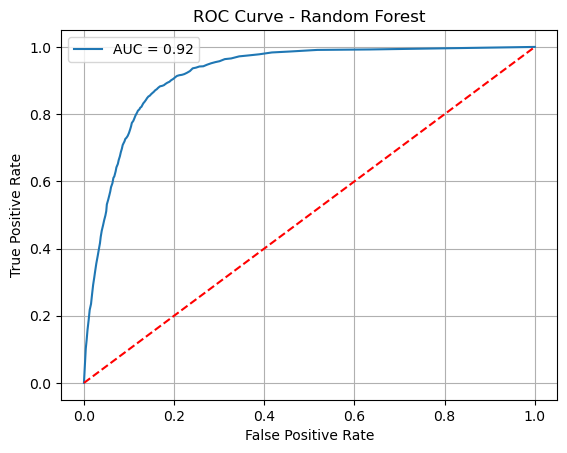

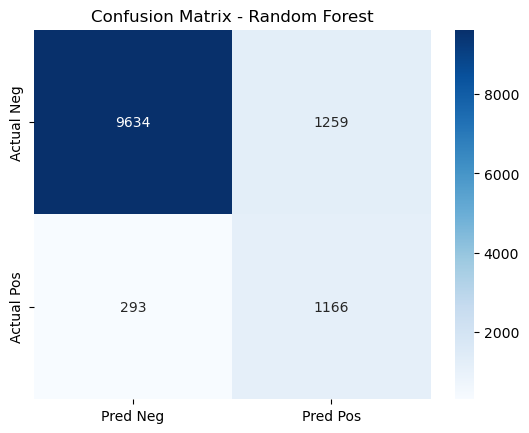

In [67]:
# Random Forest
random_forest = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
random_forest.fit(x_resampled, y_resampled)
y_pred = random_forest.predict(x_test)
y_prob = random_forest.predict_proba(x_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_prob)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nRandom Forest Metrics:")
print(f"Accuracy:  {acc:.4f} | AUC: {auc_val:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_val:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])
plt.title('Confusion Matrix - Random Forest')
plt.show()